**Import Dataset**

In [16]:
# -----------------------------------------------
# STEP 1: DATA LOADING
# -----------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the CSV file
# parse_dates converts timestamp column from text to actual datetime
df = pd.read_csv(
    'cpu_utilization_asg_misconfiguration.csv',
    parse_dates=['timestamp']
)

# Dataset shape
print("Total Rows    :", df.shape[0])
print("Total Columns :", df.shape[1])

# Column names and data types
print("\nColumn Names and Data Types:")
print(df.dtypes)

# Missing values check
print("\nMissing Values:")
print(df.isnull().sum())

# Preview first 9 rows
print("\nFirst 9 Rows:")
print(df.head(9))

# Time range and value range
print("\nTime Range :", df['timestamp'].min(), "-", df['timestamp'].max())
print("CPU Range  :", df['value'].min(), "-", df['value'].max())

# Summary statistics
print("\nCPU Value Summary:")
print(df['value'].describe())

Total Rows    : 18050
Total Columns : 2

Column Names and Data Types:
timestamp    datetime64[ns]
value               float64
dtype: object

Missing Values:
timestamp    0
value        0
dtype: int64

First 9 Rows:
            timestamp   value
0 2014-05-14 01:14:00  85.835
1 2014-05-14 01:19:00  88.167
2 2014-05-14 01:24:00  44.595
3 2014-05-14 01:29:00  56.282
4 2014-05-14 01:34:00  36.534
5 2014-05-14 01:39:00  36.894
6 2014-05-14 01:44:00  36.807
7 2014-05-14 01:49:00  36.763
8 2014-05-14 01:54:00  36.167

Time Range : 2014-05-14 01:14:00 - 2014-07-15 17:19:00
CPU Range  : 11.529000000000002 - 100.0

CPU Value Summary:
count    18050.000000
mean        38.282756
std         15.639294
min         11.529000
25%         30.789000
50%         32.001000
75%         35.660500
max        100.000000
Name: value, dtype: float64


**Preprocessing**

In [17]:
# -----------------------------------------------
# STEP 2: DATA PREPROCESSING
# -----------------------------------------------
from sklearn.preprocessing import StandardScaler

# 1. Check missing values
print("Missing values:")
print(df.isnull().sum())

# 2. Confirm timestamp is datetime
print("\nTimestamp dtype:", df['timestamp'].dtype)

# 3. Sort by time
df = df.sort_values('timestamp').reset_index(drop=True)
print("Sorted by time ")

# 4. Scale CPU values using StandardScaler
# StandardScaler: mean=0, std=1 — best for anomaly detection
scaler = StandardScaler()
df['value_scaled'] = scaler.fit_transform(df[['value']])

print("\nOriginal — mean:", round(df['value'].mean(), 2),
      "| std:", round(df['value'].std(), 2))
print("Scaled   — mean:", round(df['value_scaled'].mean(), 2),
      "| std:", round(df['value_scaled'].std(), 2))

print("\nPreprocessing complete! Shape:", df.shape)
df.head()

Missing values:
timestamp    0
value        0
dtype: int64

Timestamp dtype: datetime64[ns]
Sorted by time 

Original — mean: 38.28 | std: 15.64
Scaled   — mean: -0.0 | std: 1.0

Preprocessing complete! Shape: (18050, 3)


,timestamp,value,value_scaled
0,2014-05-14 01:14:00,85.835,3.040646
1,2014-05-14 01:19:00,88.167,3.189762
2,2014-05-14 01:24:00,44.595,0.403626
3,2014-05-14 01:29:00,56.282,1.150931
4,2014-05-14 01:34:00,36.534,-0.111821


**Visualization**

Normal readings : 17315
Spike readings  : 735 (CPU > 80%)


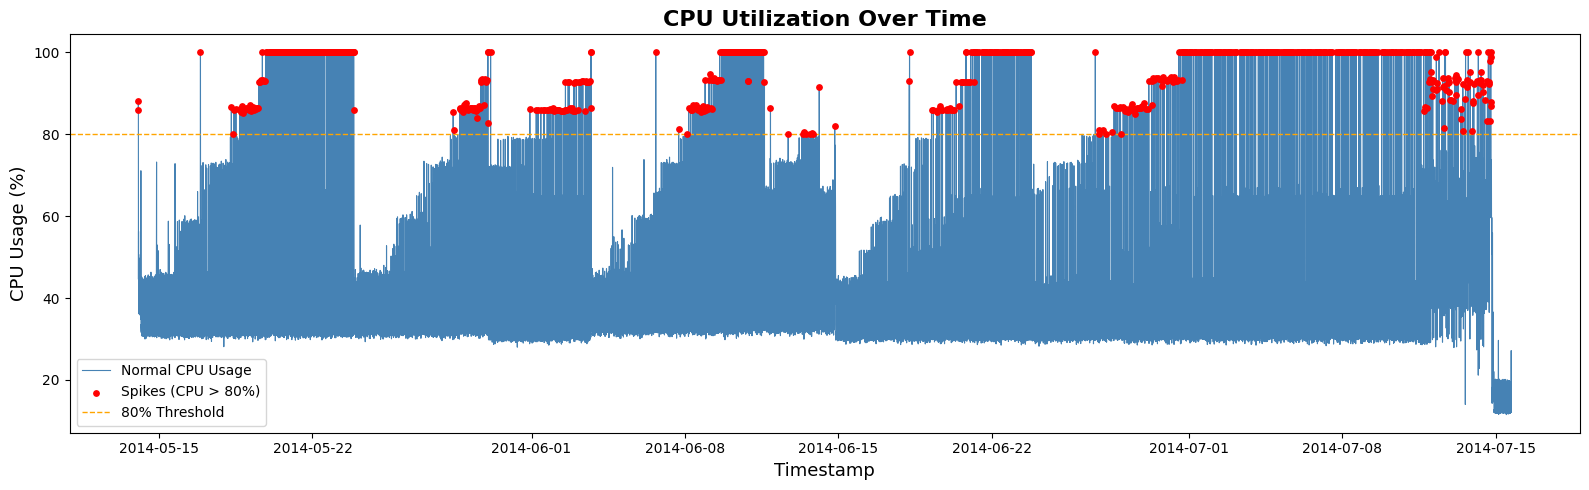


Total spikes detected : 735
Spike percentage      : 4.07%


In [18]:
# -----------------------------------------------
# STEP 3: VISUALIZATION
# -----------------------------------------------

# Separate normal and spike points
normal = df[df['value'] <= 80]
spikes = df[df['value'] > 80]

print(f"Normal readings : {len(normal)}")
print(f"Spike readings  : {len(spikes)} (CPU > 80%)")

# Plot
plt.figure(figsize=(16, 5))

# Normal CPU line
plt.plot(df['timestamp'], df['value'],
         color='steelblue', linewidth=0.8, label='Normal CPU Usage')

# Spikes in red
plt.scatter(spikes['timestamp'], spikes['value'],
            color='red', s=15, zorder=5, label='Spikes (CPU > 80%)')

plt.title('CPU Utilization Over Time', fontsize=16, fontweight='bold')
plt.xlabel('Timestamp', fontsize=13)
plt.ylabel('CPU Usage (%)', fontsize=13)
plt.axhline(y=80, color='orange', linestyle='--', linewidth=1, label='80% Threshold')
plt.legend()
plt.tight_layout()
plt.savefig('cpu_visualization.png', dpi=300)
plt.show()

print(f"\nTotal spikes detected : {len(spikes)}")
print(f"Spike percentage      : {round(len(spikes)/len(df)*100, 2)}%")

**Statistical Anomaly Detection**

Mean CPU        : 38.28%
Std Deviation   : 15.64%
Threshold (μ+2σ): 69.56%

Anomalies detected : 1200
Anomaly percentage : 6.65%


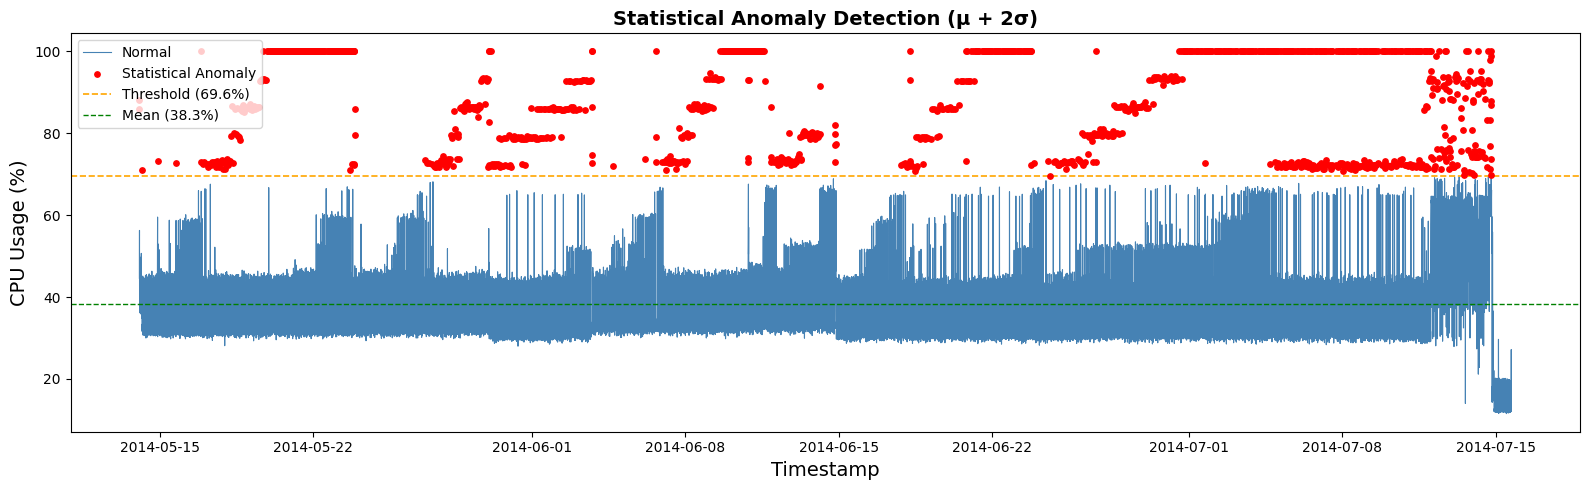


Statistical anomaly detection complete!


In [19]:
# -----------------------------------------------
# STEP 4: STATISTICAL ANOMALY DETECTION
# -----------------------------------------------

# Calculate mean and standard deviation
mean_cpu = df['value'].mean()
std_cpu  = df['value'].std()

# Threshold: mean + 2 * std
threshold = mean_cpu + 2 * std_cpu

print(f"Mean CPU        : {round(mean_cpu, 2)}%")
print(f"Std Deviation   : {round(std_cpu, 2)}%")
print(f"Threshold (μ+2σ): {round(threshold, 2)}%")

# Flag anomalies
df['stat_anomaly'] = df['value'] > threshold

# Count
anomaly_count = df['stat_anomaly'].sum()
print(f"\nAnomalies detected : {anomaly_count}")
print(f"Anomaly percentage : {round(anomaly_count/len(df)*100, 2)}%")

# Visualize
normal_stat   = df[df['stat_anomaly'] == False]
anomaly_stat  = df[df['stat_anomaly'] == True]

plt.figure(figsize=(16, 5))
plt.plot(normal_stat['timestamp'], normal_stat['value'],
         color='steelblue', linewidth=0.8, label='Normal')
plt.scatter(anomaly_stat['timestamp'], anomaly_stat['value'],
            color='red', s=15, zorder=5, label='Statistical Anomaly')
plt.axhline(y=threshold, color='orange', linestyle='--',
            linewidth=1.2, label=f'Threshold ({round(threshold,1)}%)')
plt.axhline(y=mean_cpu, color='green', linestyle='--',
            linewidth=1, label=f'Mean ({round(mean_cpu,1)}%)')

plt.title('Statistical Anomaly Detection (μ + 2σ)', fontsize=14, fontweight='bold')
plt.xlabel('Timestamp', fontsize=14)
plt.ylabel('CPU Usage (%)', fontsize=14)
plt.legend()
plt.tight_layout()
plt.savefig('statistical_anomalies.png', dpi=300)
plt.show()

print("\nStatistical anomaly detection complete!")

Isolation Forest anomalies : 1076
Statistical anomalies      : 1200

IF Anomaly percentage      : 5.96%

Agreed by both methods     : 826
Only Isolation Forest      : 250
Only Statistical           : 374


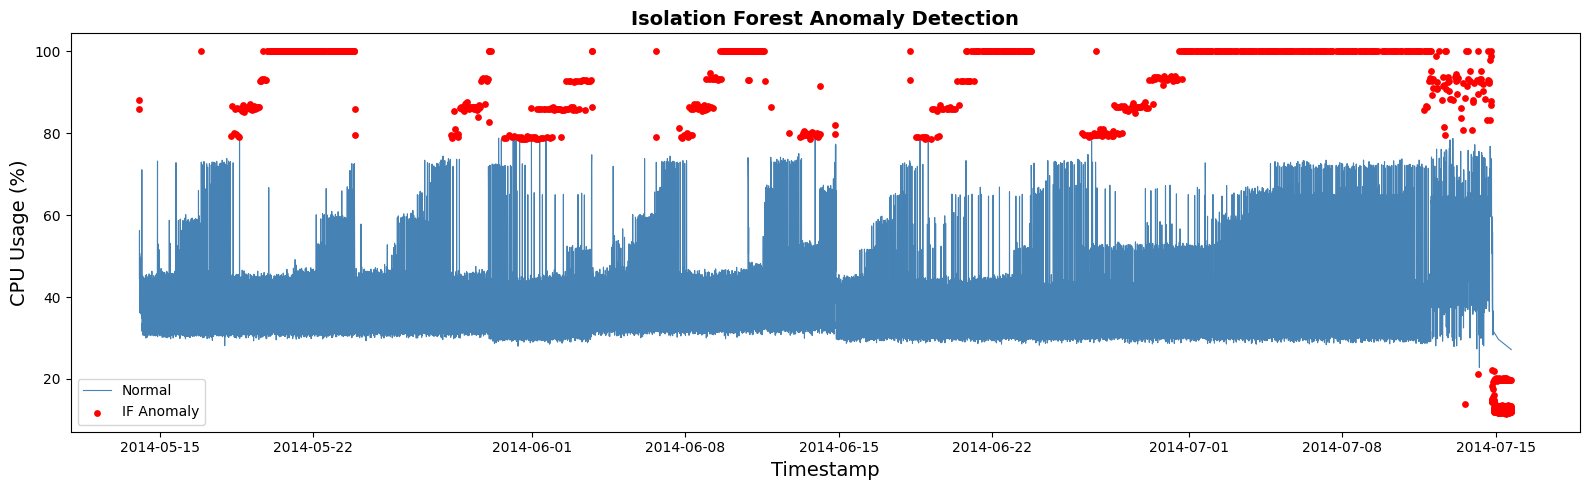


 Isolation Forest detection complete!


In [20]:
# -----------------------------------------------
# STEP 5: ML ANOMALY DETECTION — ISOLATION FOREST
# -----------------------------------------------
from sklearn.ensemble import IsolationForest

# Isolation Forest trains on CPU values
# contamination = expected % of anomalies in data
# We saw ~6% from statistical method, so use 0.06
iso_forest = IsolationForest(
    contamination=0.06,
    random_state=42,
    n_estimators=100
)

# Train and predict on scaled values
# -1 = anomaly, 1 = normal
df['if_anomaly'] = iso_forest.fit_predict(df[['value_scaled']])

# Convert to True/False for easy reading
df['if_anomaly'] = df['if_anomaly'] == -1

# Count
if_count = df['if_anomaly'].sum()
print(f"Isolation Forest anomalies : {if_count}")
print(f"Statistical anomalies      : {df['stat_anomaly'].sum()}")
print(f"\nIF Anomaly percentage      : {round(if_count/len(df)*100, 2)}%")

# Compare both methods
both    = df[df['stat_anomaly'] & df['if_anomaly']]
only_if = df[~df['stat_anomaly'] & df['if_anomaly']]
only_st = df[df['stat_anomaly'] & ~df['if_anomaly']]

print(f"\nAgreed by both methods     : {len(both)}")
print(f"Only Isolation Forest      : {len(only_if)}")
print(f"Only Statistical           : {len(only_st)}")

# Visualize
plt.figure(figsize=(16, 5))

normal_if  = df[df['if_anomaly'] == False]
anomaly_if = df[df['if_anomaly'] == True]

plt.plot(normal_if['timestamp'], normal_if['value'],
         color='steelblue', linewidth=0.8, label='Normal')
plt.scatter(anomaly_if['timestamp'], anomaly_if['value'],
            color='red', s=15, zorder=5, label='IF Anomaly')

plt.title('Isolation Forest Anomaly Detection', fontsize=14, fontweight='bold')
plt.xlabel('Timestamp', fontsize=14)
plt.ylabel('CPU Usage (%)', fontsize=14)
plt.legend()
plt.tight_layout()
plt.savefig('isolation_forest_anomalies.png', dpi=300)
plt.show()

print("\n Isolation Forest detection complete!")

**Real-time Simulation + Alert System**

In [21]:
# -----------------------------------------------
# STEP 6: REAL-TIME SIMULATION + ALERT SYSTEM
# -----------------------------------------------
import time
import os

# Create logs folder
os.makedirs('logs', exist_ok=True)
log_file = 'logs/anomaly_alerts.txt'

# Clear old log
open(log_file, 'w').close()

print("=" * 55)
print("  REAL-TIME CPU MONITORING SIMULATION")
print("=" * 55)
print("Processing last 50 rows as live stream...\n")

# Simulate last 50 rows as streaming data
stream_data = df.tail(50).reset_index(drop=True)

alert_count = 0

for i, row in stream_data.iterrows():
    cpu   = row['value']
    ts    = row['timestamp']
    is_if = row['if_anomaly']
    is_st = row['stat_anomaly']

    # Determine alert level
    if is_if and is_st:
        level  = "CRITICAL"
        reason = "Flagged by both Statistical and Isolation Forest"
    elif is_if:
        level  = "WARNING"
        reason = "Isolation Forest detected unusual pattern"
    elif is_st:
        level  = "WARNING"
        reason = f"CPU exceeded threshold ({round(threshold, 1)}%)"
    else:
        level  = None

    if level:
        alert_count += 1
        msg = f"[{level}] {ts} | CPU: {round(cpu, 2)}% | {reason}"
        print(msg)

        # Save to log file
        with open(log_file, 'a') as f:
            f.write(msg + '\n')

    time.sleep(0.05)  # simulate streaming delay

print(f"\n{'='*55}")
print(f"Simulation complete!")
print(f"Total alerts generated : {alert_count}")
print(f"Logs saved to         : {log_file}")
print(f"{'='*55}")

  REAL-TIME CPU MONITORING SIMULATION
Processing last 50 rows as live stream...

[WARNING] 2014-07-15 13:14:00 | CPU: 12.79% | Isolation Forest detected unusual pattern
[WARNING] 2014-07-15 13:19:00 | CPU: 12.03% | Isolation Forest detected unusual pattern
[WARNING] 2014-07-15 13:24:00 | CPU: 11.97% | Isolation Forest detected unusual pattern
[WARNING] 2014-07-15 13:29:00 | CPU: 12.65% | Isolation Forest detected unusual pattern
[WARNING] 2014-07-15 13:34:00 | CPU: 12.32% | Isolation Forest detected unusual pattern
[WARNING] 2014-07-15 13:39:00 | CPU: 11.69% | Isolation Forest detected unusual pattern
[WARNING] 2014-07-15 13:44:00 | CPU: 12.62% | Isolation Forest detected unusual pattern
[WARNING] 2014-07-15 13:49:00 | CPU: 12.0% | Isolation Forest detected unusual pattern
[WARNING] 2014-07-15 13:54:00 | CPU: 11.87% | Isolation Forest detected unusual pattern
[WARNING] 2014-07-15 13:59:00 | CPU: 13.62% | Isolation Forest detected unusual pattern
[WARNING] 2014-07-15 14:04:00 | CPU: 19.

In [22]:
# -----------------------------------------------
# STEP 7: STORAGE LAYER
# -----------------------------------------------
import os

os.makedirs('outputs', exist_ok=True)

# Save all anomalies to CSV
anomalies_df = df[df['if_anomaly'] | df['stat_anomaly']].copy()

anomalies_df['alert_reason'] = anomalies_df.apply(
    lambda row:
    'Critical: Both methods flagged' if row['if_anomaly'] and row['stat_anomaly']
    else 'Warning: Isolation Forest'  if row['if_anomaly']
    else 'Warning: Statistical threshold',
    axis=1
)

# Save to CSV
anomalies_df[['timestamp', 'value', 'stat_anomaly',
              'if_anomaly', 'alert_reason']].to_csv(
    'outputs/anomaly_log.csv', index=False
)

print(f"✅ Anomaly log saved!")
print(f"Total anomalies stored : {len(anomalies_df)}")
print(f"File location          : outputs/anomaly_log.csv")
print()
print("Sample records:")
print(anomalies_df[['timestamp','value','alert_reason']].head(5).to_string(index=False))

✅ Anomaly log saved!
Total anomalies stored : 1450
File location          : outputs/anomaly_log.csv

Sample records:
          timestamp  value                   alert_reason
2014-05-14 01:14:00 85.835 Critical: Both methods flagged
2014-05-14 01:19:00 88.167 Critical: Both methods flagged
2014-05-14 04:04:00 71.106 Warning: Statistical threshold
2014-05-14 21:14:00 73.229 Warning: Statistical threshold
2014-05-15 17:29:00 72.835 Warning: Statistical threshold


**Dashboard**

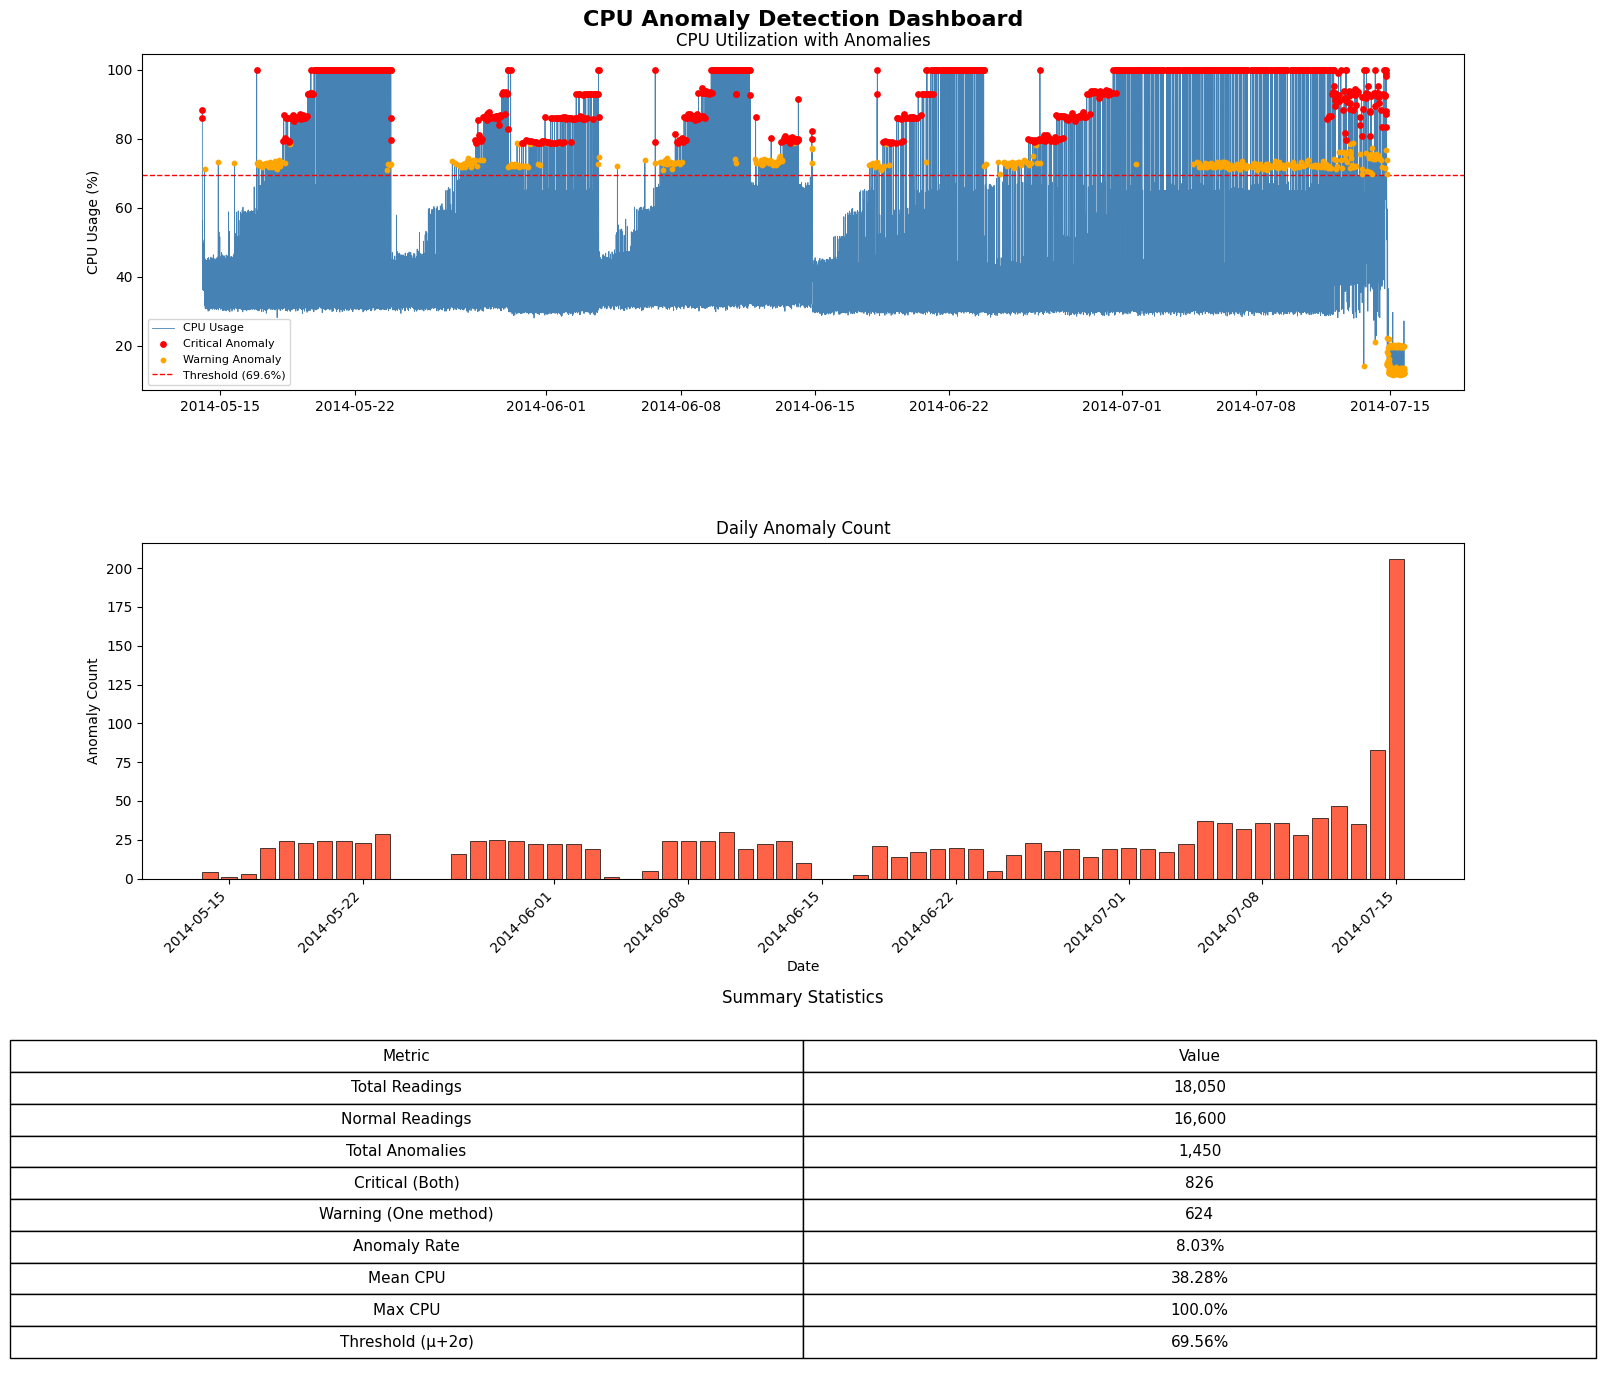

Dashboard saved to outputs/dashboard.png


In [23]:
# -----------------------------------------------
# STEP 8: DASHBOARD VISUALIZATION
# -----------------------------------------------

fig, axes = plt.subplots(3, 1, figsize=(16, 14))
fig.suptitle('CPU Anomaly Detection Dashboard',
             fontsize=16, fontweight='bold', y=0.98)

# --- Plot 1: Full CPU with both anomalies ---
ax1 = axes[0]
ax1.plot(df['timestamp'], df['value'],
         color='steelblue', linewidth=0.6, label='CPU Usage', zorder=1)

critical = df[df['if_anomaly'] & df['stat_anomaly']]
warning  = df[df['if_anomaly'] ^ df['stat_anomaly']]

ax1.scatter(critical['timestamp'], critical['value'],
            color='red', s=15, zorder=5, label='Critical Anomaly')
ax1.scatter(warning['timestamp'], warning['value'],
            color='orange', s=10, zorder=4, label='Warning Anomaly')
ax1.axhline(y=threshold, color='red', linestyle='--',
            linewidth=1, label=f'Threshold ({round(threshold,1)}%)')
ax1.set_title('CPU Utilization with Anomalies', fontsize=12)
ax1.set_ylabel('CPU Usage (%)')
ax1.legend(fontsize=8)

# --- Plot 2: Anomaly count per day ---
ax2 = axes[1]
anomalies_df['date'] = anomalies_df['timestamp'].dt.date
daily_counts = anomalies_df.groupby('date').size()

ax2.bar(daily_counts.index, daily_counts.values,
        color='tomato', edgecolor='black', linewidth=0.5)
ax2.set_title('Daily Anomaly Count', fontsize=12)
ax2.set_ylabel('Anomaly Count')
ax2.set_xlabel('Date')
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right')

# --- Plot 3: Statistics summary ---
ax3 = axes[2]
ax3.axis('off')

stats = [
    ['Total Readings',        f"{len(df):,}"],
    ['Normal Readings',       f"{len(df) - len(anomalies_df):,}"],
    ['Total Anomalies',       f"{len(anomalies_df):,}"],
    ['Critical (Both)',       f"{len(critical):,}"],
    ['Warning (One method)',  f"{len(warning):,}"],
    ['Anomaly Rate',          f"{round(len(anomalies_df)/len(df)*100, 2)}%"],
    ['Mean CPU',              f"{round(df['value'].mean(), 2)}%"],
    ['Max CPU',               f"{round(df['value'].max(), 2)}%"],
    ['Threshold (μ+2σ)',      f"{round(threshold, 2)}%"],
]

table = ax3.table(
    cellText=stats,
    colLabels=['Metric', 'Value'],
    loc='center',
    cellLoc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 1.8)
ax3.set_title('Summary Statistics', fontsize=12, pad=20)

plt.tight_layout()
plt.savefig('outputs/dashboard.png', dpi=300, bbox_inches='tight')
plt.show()

print("Dashboard saved to outputs/dashboard.png")

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but IsolationForest was fitted without feature names
  warnings.warn(


PyOD anomalies detected  : 1076
Isolation Forest detected: 1076
Difference               : 0


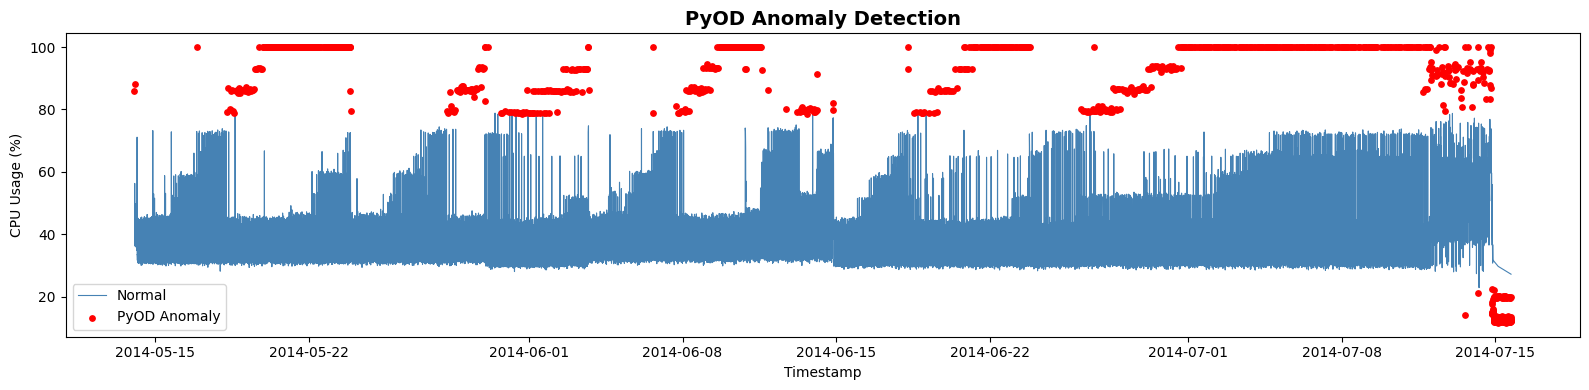

 PyOD detection complete!


In [24]:
# -----------------------------------------------
# STEP 9: PyOD ANOMALY DETECTION
# -----------------------------------------------
# Install karo pehle
!pip install pyod -q

from pyod.models.iforest import IForest
import numpy as np

# PyOD ka Isolation Forest
pyod_model = IForest(contamination=0.06, random_state=42)
pyod_model.fit(df[['value_scaled']])

# Predict — 1 = anomaly, 0 = normal
df['pyod_anomaly'] = pyod_model.predict(df[['value_scaled']])
df['pyod_anomaly'] = df['pyod_anomaly'] == 1

pyod_count = df['pyod_anomaly'].sum()
print(f"PyOD anomalies detected  : {pyod_count}")
print(f"Isolation Forest detected: {df['if_anomaly'].sum()}")
print(f"Difference               : {abs(pyod_count - df['if_anomaly'].sum())}")

# Quick plot
plt.figure(figsize=(16, 4))
normal_pyod  = df[df['pyod_anomaly'] == False]
anomaly_pyod = df[df['pyod_anomaly'] == True]

plt.plot(normal_pyod['timestamp'], normal_pyod['value'],
         color='steelblue', linewidth=0.8, label='Normal')
plt.scatter(anomaly_pyod['timestamp'], anomaly_pyod['value'],
            color='red', s=15, zorder=5, label='PyOD Anomaly')

plt.title('PyOD Anomaly Detection', fontsize=14, fontweight='bold')
plt.xlabel('Timestamp')
plt.ylabel('CPU Usage (%)')
plt.legend()
plt.tight_layout()
plt.savefig('outputs/pyod_anomalies.png', dpi=300)
plt.show()

print(" PyOD detection complete!")